In [1]:
import os
import pandas as pd
import numpy as np

# ------------- LOAD AND CLEAN NIFTY 100 PRICE DATA -------------
folder_path = "NIFTY100_Sectors"
price_data = {}

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        stock_name = file.replace(".csv", "")
        df = pd.read_csv(os.path.join(folder_path, file))
        
        # Handle different date/time index
        date_column_found = False
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"])
            df.set_index("Date", inplace=True)
            date_column_found = True
        elif "Timestamp" in df.columns:
            df["Timestamp"] = pd.to_datetime(df["Timestamp"])
            df.set_index("Timestamp", inplace=True)
            date_column_found = True
        if not date_column_found:
            try:
                df.index = pd.to_datetime(df.index)
                date_column_found = True
                print(f"✅ {stock_name}: Date found in index")
            except:
                pass
        if not date_column_found:
            print(f" WARNING: No date column found in {file}. Skipping...")
            continue
        # Use first available price column
        if "Adj Close" in df.columns:
            price_series = df["Adj Close"]
        elif "Close" in df.columns:
            price_series = df["Close"]
        elif "Price" in df.columns:
            price_series = df["Price"]
        else:
            print(f"⚠WARNING: No price column in {file}. Skipping...")
            continue
        price_data[stock_name] = price_series
        print(f"✅ {stock_name}: Successfully loaded {len(df)} records")

if not price_data:
    raise ValueError("No stock data was successfully loaded!")

prices = pd.DataFrame(price_data)
prices.index = pd.to_datetime(prices.index)
prices = prices[~prices.index.duplicated(keep='first')]
prices = prices.sort_index()
prices = prices.dropna(how="any")   # Drop rows where any stock is missing

# Remove any row where at least one value cannot be converted to float (keeps only valid data rows)
def is_numeric_row(row):
    try:
        [float(x) for x in row]
        return True
    except:
        return False

prices = prices[prices.apply(is_numeric_row, axis=1)]
prices = prices.astype(float)

✅ LUPIN: Date found in index
✅ LUPIN: Successfully loaded 1241 records
✅ WIPRO: Date found in index
✅ WIPRO: Successfully loaded 1242 records
✅ DRREDDY: Date found in index
✅ DRREDDY: Successfully loaded 1241 records
✅ TECHM: Date found in index
✅ TECHM: Successfully loaded 1241 records
✅ TCS: Date found in index
✅ TCS: Successfully loaded 1242 records
✅ SUNPHARMA: Date found in index
✅ SUNPHARMA: Successfully loaded 1241 records
✅ HCLTECH: Date found in index
✅ HCLTECH: Successfully loaded 1242 records
✅ BIOCON: Date found in index
✅ BIOCON: Successfully loaded 1241 records
✅ CIPLA: Date found in index
✅ CIPLA: Successfully loaded 1241 records
✅ INFY: Date found in index
✅ INFY: Successfully loaded 1242 records
✅ AUROPHARMA: Date found in index
✅ AUROPHARMA: Successfully loaded 1241 records
✅ DIVISLAB: Date found in index
✅ DIVISLAB: Successfully loaded 1241 records


In [2]:
# ===================== MPT CALCULATIONS ===========================
# 1. Calculate log returns
returns = np.log(prices / prices.shift(1)).dropna()
# Or: returns = prices.pct_change().dropna()

# 2. Expected returns (annualized)
mean_returns_daily = returns.mean()
mean_returns_annual = mean_returns_daily * 252  # 252 trading days

# 3. Covariance matrix (annualized)
cov_matrix_daily = returns.cov()
cov_matrix_annual = cov_matrix_daily * 252

# 4. Risk-free rate
rf = 0.06

# 5. Max Sharpe/Tangency Portfolio weights (no shorting constraints)
inv_cov = np.linalg.pinv(cov_matrix_annual.values)
ones = np.ones(len(mean_returns_annual))
excess_returns = mean_returns_annual - rf
w_tan = inv_cov @ excess_returns
w_tan = w_tan / np.sum(w_tan)  # sum to 1

# Portfolio stats
port_ret = w_tan @ mean_returns_annual
port_vol = np.sqrt(w_tan.T @ cov_matrix_annual.values @ w_tan)
sharpe = (port_ret - rf) / port_vol

# -------------- OUTPUT --------------
print("\n--- MPT / Tangency Portfolio ---")
for name, weight in zip(prices.columns, w_tan):
    print(f"{name:20s}: {weight:.2%}")
print(f"\nExpected annual return: {port_ret:.2%}")
print(f"Portfolio volatility:   {port_vol:.2%}")
print(f"Sharpe ratio:           {sharpe:.2f}")


--- MPT / Tangency Portfolio ---
LUPIN               : 8.60%
WIPRO               : 7.43%
DRREDDY             : -45.60%
TECHM               : 22.00%
TCS                 : -45.91%
SUNPHARMA           : 122.04%
HCLTECH             : 51.74%
BIOCON              : -50.17%
CIPLA               : 24.75%
INFY                : 11.05%
AUROPHARMA          : -20.98%
DIVISLAB            : 15.04%

Expected annual return: 46.31%
Portfolio volatility:   31.16%
Sharpe ratio:           1.29


In [60]:
cov_matrix_annual

,LUPIN,WIPRO,DRREDDY,TECHM,TCS,SUNPHARMA,HCLTECH,BIOCON,CIPLA,INFY,AUROPHARMA,DIVISLAB
LUPIN,0.080203,0.001592,0.025788,0.018996,0.000022,0.029040,0.001410,0.034935,0.031069,-0.000541,0.042382,0.031391
WIPRO,0.001592,0.070677,0.001833,0.001316,0.034475,-0.000497,0.039652,0.004546,0.002264,0.041332,0.002191,0.001246
DRREDDY,0.025788,0.001833,0.049042,0.014975,0.001301,0.018789,0.001369,0.021268,0.023550,0.000537,0.028290,0.021156
TECHM,0.018996,0.001316,0.014975,0.075967,0.003301,0.016798,0.002117,0.021557,0.011617,0.003472,0.020694,0.020044
TCS,0.000022,0.034475,0.001301,0.003301,0.044896,0.000583,0.033487,0.004259,0.000671,0.035958,0.001617,0.001624
SUNPHARMA,0.029040,-0.000497,0.018789,0.016798,0.000583,0.046967,0.001668,0.022383,0.021870,-0.000294,0.027792,0.020879
HCLTECH,0.001410,0.039652,0.001369,0.002117,0.033487,0.001668,0.061108,0.004535,0.001042,0.040421,0.001976,0.005311
BIOCON,0.034935,0.004546,0.021268,0.021557,0.004259,0.022383,0.004535,0.103205,0.022818,0.004370,0.035706,0.029677
CIPLA,0.031069,0.002264,0.023550,0.011617,0.000671,0.021870,0.001042,0.022818,0.055264,0.000691,0.028176,0.021491
INFY,-0.000541,0.041332,0.000537,0.003472,0.035958,-0.000294,0.040421,0.004370,0.000691,0.059439,0.000311,0.000986


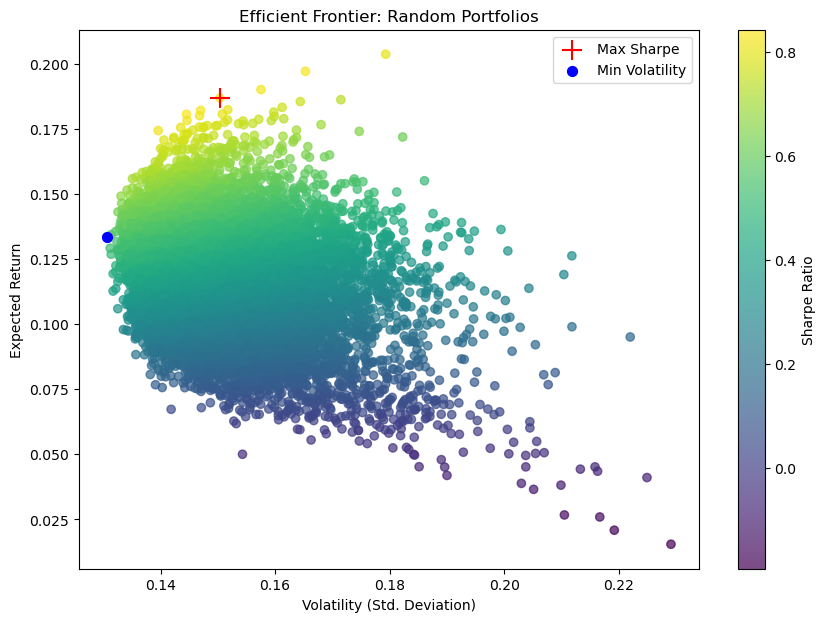

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate daily returns
returns = np.log(prices / prices.shift(1)).dropna()
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
num_assets = len(prices.columns)
num_portfolios = 15_000

results = np.zeros((3, num_portfolios))  # rows: [returns, volatility, sharpe]
weights_record = []

rf = 0.06

for i in range(num_portfolios):
    # Random weights that sum to 1
    weights = np.random.dirichlet(np.ones(num_assets), 1)[0]
    weights_record.append(weights)
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_vol = np.sqrt(weights @ cov_matrix.values @ weights)
    portfolio_sharpe = (portfolio_return - rf) / portfolio_vol
    results[0,i] = portfolio_return
    results[1,i] = portfolio_vol
    results[2,i] = portfolio_sharpe

# Find max Sharpe and min volatility portfolio
max_sharpe_idx = np.argmax(results[2])
min_vol_idx = np.argmin(results[1])
sdp_max, rp_max = results[1,max_sharpe_idx], results[0,max_sharpe_idx]
sdp_min, rp_min = results[1,min_vol_idx], results[0,min_vol_idx]

# Plot
plt.figure(figsize=(10,7))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Std. Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier: Random Portfolios')
plt.scatter(sdp_max, rp_max, marker='+', color='r', s=200, label='Max Sharpe')
plt.scatter(sdp_min, rp_min, marker='.', color='b', s=200, label='Min Volatility')
plt.legend()
plt.show()

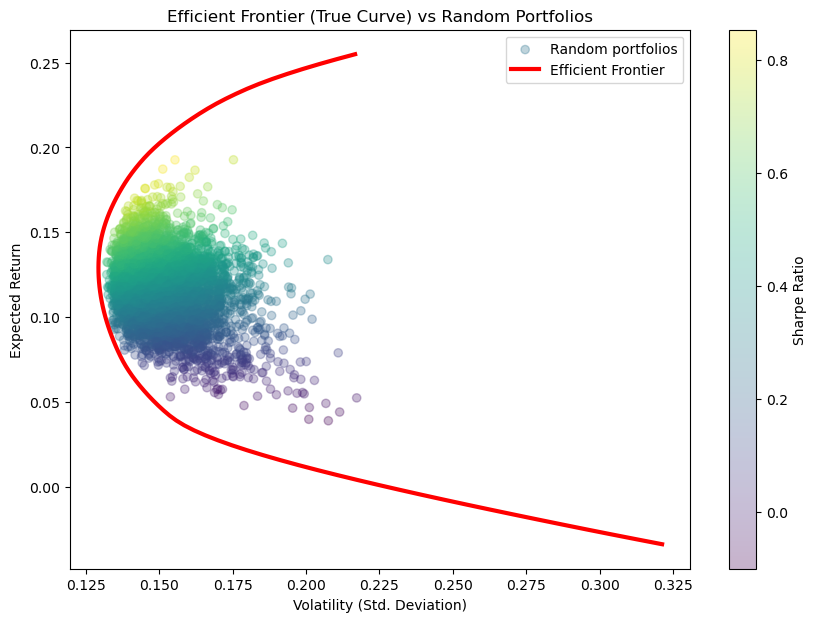

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Prepare returns/covariance as before
returns = np.log(prices / prices.shift(1)).dropna()
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
num_assets = len(mean_returns)
rf = 0.06

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

# Efficient frontier calculation function
def min_variance(mean_returns, cov_matrix, target_return):
    num_assets = len(mean_returns)
    def constraint_ret(weights):
        return weights @ mean_returns - target_return
    constraints = (
        {'type':'eq', 'fun': lambda w: np.sum(w) - 1},  # Weights sum to 1
        {'type':'eq', 'fun': constraint_ret}
    )
    bounds = tuple((0,1) for _ in range(num_assets))
    result = minimize(portfolio_volatility, 
                      x0=np.repeat(1/num_assets, num_assets),
                      args=(mean_returns, cov_matrix),
                      method='SLSQP',
                      constraints=constraints,
                      bounds=bounds)
    return result

target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 100)
frontier_risk = []
frontier_weights = []

for ret in target_returns:
    res = min_variance(mean_returns, cov_matrix, ret)
    if res.success:
        frontier_risk.append(portfolio_volatility(res.x, mean_returns, cov_matrix))
        frontier_weights.append(res.x)
    else:
        # If optimizer failed (can happen at edges), skip point
        frontier_risk.append(np.nan)
        frontier_weights.append([np.nan]*num_assets)

# --- Plot efficient frontier curve and random portfolios ---
# Simulate random portfolios (as before) for visual context
np.random.seed(42)
num_portfolios = 6000
random_returns = []
random_risk = []
random_sharpe = []
for _ in range(num_portfolios):
    w = np.random.dirichlet(np.ones(num_assets))
    ret = np.sum(w * mean_returns)
    risk = np.sqrt(w @ cov_matrix @ w)
    sharpe = (ret - rf) / risk
    random_returns.append(ret)
    random_risk.append(risk)
    random_sharpe.append(sharpe)

plt.figure(figsize=(10,7))
plt.scatter(random_risk, random_returns, c=random_sharpe, cmap='viridis', alpha=0.3, label='Random portfolios')
plt.plot(frontier_risk, target_returns, 'r-', linewidth=3, label='Efficient Frontier')
plt.xlabel('Volatility (Std. Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (True Curve) vs Random Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.show()

In [29]:
!pip install PyPortfolioOpt

In [30]:
from pypfopt.black_litterman import BlackLittermanModel, market_implied_risk_aversion, market_implied_prior_returns
from pypfopt import risk_models, expected_returns, EfficientFrontier

# Black-Litterman Model

In [6]:
import numpy as np
import pandas as pd

In [7]:
# ============ BLACK-LITTERMAN MODEL IMPLEMENTATION ============

# Step 1: Calculate Market-Implied Risk Aversion (δ)
# This represents the market's price of risk
market_returns = prices.pct_change().dropna()
market_portfolio_return = (w_tan @ mean_returns_annual)
market_portfolio_variance = w_tan.T @ cov_matrix_annual.values @ w_tan

delta = (market_portfolio_return - rf) / market_portfolio_variance
print(f"\n--- Market-Implied Risk Aversion (δ) ---")
print(f"Delta: {delta:.4f}")


--- Market-Implied Risk Aversion (δ) ---
Delta: 4.1511


In [8]:
# Step 2: Calculate Implied Equilibrium Returns (Π)
# These are the returns implied by current market weights
market_weights = np.array([1/len(prices.columns)] * len(prices.columns))  
# Or use actual market cap weights if available
Pi = delta * cov_matrix_annual.values @ market_weights
print(f"\n--- Implied Equilibrium Returns (Π) ---")
for name, ret in zip(prices.columns, Pi):
    print(f"{name:20s}: {ret:.2%}")



--- Implied Equilibrium Returns (Π) ---
LUPIN               : 10.25%
WIPRO               : 6.94%
DRREDDY             : 7.19%
TECHM               : 7.29%
TCS                 : 5.61%
SUNPHARMA           : 7.13%
HCLTECH             : 6.71%
BIOCON              : 10.70%
CIPLA               : 7.63%
INFY                : 6.46%
AUROPHARMA          : 10.84%
DIVISLAB            : 9.01%


In [9]:
# Step 3: Specify Your Views
# Define K views on the assets
# Example views (you should customize these based on your analysis):

# View 1: Tech sector (e.g., Infosys, TCS, Wipro) will outperform by 5%
# View 2: Pharma sector (e.g., Lupin, Dr. Reddy's) will underperform by -2%
# View 3: Specific stock (e.g., HCLTech) will have absolute return of 8%

# Q: View vector (Kx1) - the expected returns from your views
Q = np.array([
    0.05,   # View 1: Tech outperforms by 5%
    -0.02,  # View 2: Pharma underperforms by 2%
    0.08    # View 3: HCLTech returns 8%
]).reshape(-1, 1)

# P: Picking matrix (KxN) - maps views to assets
# Each row represents one view
# For relative views: positive weights for outperforming, negative for underperforming
# For absolute views: single 1 in the asset column

num_assets = len(prices.columns)
K = len(Q)  # number of views
P = np.zeros((K, num_assets))

# Example: Customize this based on your actual stock positions
# View 1: Equal weight on 3 tech stocks vs equal weight on 2 pharma stocks
# Assuming positions: [0:Lupin, 1:Wipro, 2:DrReddy, 3:TechM, 4:TCS, ...]
# You need to map this to your actual column order

# Simple example with first few stocks:
P[0, 1] = 0.33; P[0, 3] = 0.33; P[0, 4] = 0.33  # Tech stocks
P[0, 0] = -0.5; P[0, 2] = -0.5  # Pharma stocks
P[1, 0] = 0.5; P[1, 2] = 0.5  # Pharma view
P[2, 6] = 1.0  # Absolute view on one stock

print(f"\n--- Views Specification ---")
print(f"Number of views (K): {K}")
print(f"Q (views vector):\n{Q.flatten()}")
print(f"P (picking matrix) shape: {P.shape}")


--- Views Specification ---
Number of views (K): 3
Q (views vector):
[ 0.05 -0.02  0.08]
P (picking matrix) shape: (3, 12)


In [10]:
# Step 4: Uncertainty in Views (Ω)
# Tau: scalar parameter (typically 0.01 to 0.05)
tau = 0.025

# Omega: Diagonal covariance matrix of view uncertainties
# Default method: proportional to view portfolio variance
omega_diag = np.zeros(K)
for i in range(K):
    omega_diag[i] = tau * (P[i, :] @ cov_matrix_annual.values @ P[i, :].T)

Omega = np.diag(omega_diag)
print(f"\n--- Uncertainty Matrix (Ω) ---")
print(f"Tau: {tau}")
print(f"Omega diagonal: {np.diag(Omega)}")



--- Uncertainty Matrix (Ω) ---
Tau: 0.025
Omega diagonal: [0.00154503 0.00113013 0.00152771]


In [11]:
# Step 5: Calculate Posterior Returns (Black-Litterman Formula)
# E[R] = [(τΣ)^(-1) + P'Ω^(-1)P]^(-1) [(τΣ)^(-1)Π + P'Ω^(-1)Q]

tau_sigma_inv = np.linalg.inv(tau * cov_matrix_annual.values)
omega_inv = np.linalg.inv(Omega)

# Posterior covariance
M = np.linalg.inv(tau_sigma_inv + P.T @ omega_inv @ P)

# Posterior returns
posterior_returns = M @ (tau_sigma_inv @ Pi + P.T @ omega_inv @ Q.flatten())

print(f"\n--- Black-Litterman Posterior Returns ---")
for name, ret in zip(prices.columns, posterior_returns):
    print(f"{name:20s}: {ret:.2%}")



--- Black-Litterman Posterior Returns ---
LUPIN               : 3.45%
WIPRO               : 7.80%
DRREDDY             : 2.42%
TECHM               : 5.67%
TCS                 : 6.38%
SUNPHARMA           : 4.12%
HCLTECH             : 7.54%
BIOCON              : 7.26%
CIPLA               : 4.15%
INFY                : 7.36%
AUROPHARMA          : 6.39%
DIVISLAB            : 5.76%


In [12]:
# Step 6: Calculate Posterior Covariance Matrix
posterior_cov = cov_matrix_annual.values + M

In [13]:
posterior_cov

array([[ 0.08129576,  0.00175349,  0.02579511,  0.0193172 ,  0.00012562,
         0.02936706,  0.00148651,  0.0353566 ,  0.0313823 , -0.00045161,
         0.04285234,  0.03174157],
       [ 0.00175349,  0.07195149,  0.00195442,  0.00121896,  0.03493461,
        -0.00047761,  0.04007009,  0.00465705,  0.00237277,  0.04191701,
         0.00229764,  0.00127866],
       [ 0.02579511,  0.00195442,  0.04982156,  0.01523654,  0.00139879,
         0.01897954,  0.00142462,  0.02148226,  0.02381488,  0.00061533,
         0.02858398,  0.02138071],
       [ 0.0193172 ,  0.00121896,  0.01523654,  0.07771873,  0.00328571,
         0.01713901,  0.00209128,  0.02199041,  0.01182289,  0.00346767,
         0.02109492,  0.02045429],
       [ 0.00012562,  0.03493461,  0.00139879,  0.00328571,  0.04568832,
         0.00062522,  0.03384614,  0.00436569,  0.00073309,  0.03648739,
         0.00170216,  0.00166797],
       [ 0.02936706, -0.00047761,  0.01897954,  0.01713901,  0.00062522,
         0.04796599,  

In [14]:
# Step 7: Optimize Portfolio with Posterior Returns
# Method 1: Return-implied weights (simpler)
bl_weights = np.linalg.inv(delta * posterior_cov) @ posterior_returns

# Normalize weights to sum to 1
bl_weights = bl_weights / np.sum(bl_weights)

print(f"\n--- Black-Litterman Portfolio Weights ---")
for name, weight in zip(prices.columns, bl_weights):
    print(f"{name:20s}: {weight:.2%}")



--- Black-Litterman Portfolio Weights ---
LUPIN               : -9.81%
WIPRO               : 13.38%
DRREDDY             : -9.81%
TECHM               : 13.38%
TCS                 : 13.38%
SUNPHARMA           : 10.96%
HCLTECH             : 13.75%
BIOCON              : 10.96%
CIPLA               : 10.96%
INFY                : 10.96%
AUROPHARMA          : 10.96%
DIVISLAB            : 10.96%


In [15]:
# Step 8: Calculate Portfolio Performance
bl_return = bl_weights @ posterior_returns
bl_volatility = np.sqrt(bl_weights.T @ posterior_cov @ bl_weights)
bl_sharpe = (bl_return - rf) / bl_volatility

print(f"\n--- Black-Litterman Portfolio Performance ---")
print(f"Expected Annual Return: {bl_return:.2%}")
print(f"Portfolio Volatility:   {bl_volatility:.2%}")
print(f"Sharpe Ratio:           {bl_sharpe:.2f}")

# Comparison with MPT
print(f"\n--- Comparison: MPT vs Black-Litterman ---")
print(f"{'Metric':<25} {'MPT':>15} {'Black-Litterman':>15}")
print(f"{'-'*55}")
print(f"{'Expected Return':<25} {port_ret:>14.2%} {bl_return:>15.2%}")
print(f"{'Volatility':<25} {port_vol:>14.2%} {bl_volatility:>15.2%}")
print(f"{'Sharpe Ratio':<25} {sharpe:>14.2f} {bl_sharpe:>15.2f}")

# Weight differences
print(f"\n--- Weight Changes (BL - MPT) ---")
for name, mpt_w, bl_w in zip(prices.columns, w_tan, bl_weights):
    diff = bl_w - mpt_w
    print(f"{name:20s}: {diff:>7.2%}")


--- Black-Litterman Portfolio Performance ---
Expected Annual Return: 6.96%
Portfolio Volatility:   15.03%
Sharpe Ratio:           0.06

--- Comparison: MPT vs Black-Litterman ---
Metric                                MPT Black-Litterman
-------------------------------------------------------
Expected Return                   46.31%           6.96%
Volatility                        31.16%          15.03%
Sharpe Ratio                        0.16            0.06

--- Weight Changes (BL - MPT) ---
LUPIN               : -18.41%
WIPRO               :   5.95%
DRREDDY             :  35.79%
TECHM               :  -8.62%
TCS                 :  59.28%
SUNPHARMA           : -111.09%
HCLTECH             : -37.99%
BIOCON              :  61.13%
CIPLA               : -13.79%
INFY                :  -0.10%
AUROPHARMA          :  31.94%
DIVISLAB            :  -4.08%


## Bar chart: Annualized Expected Returns per Company (MPT vs Black-Litterman)

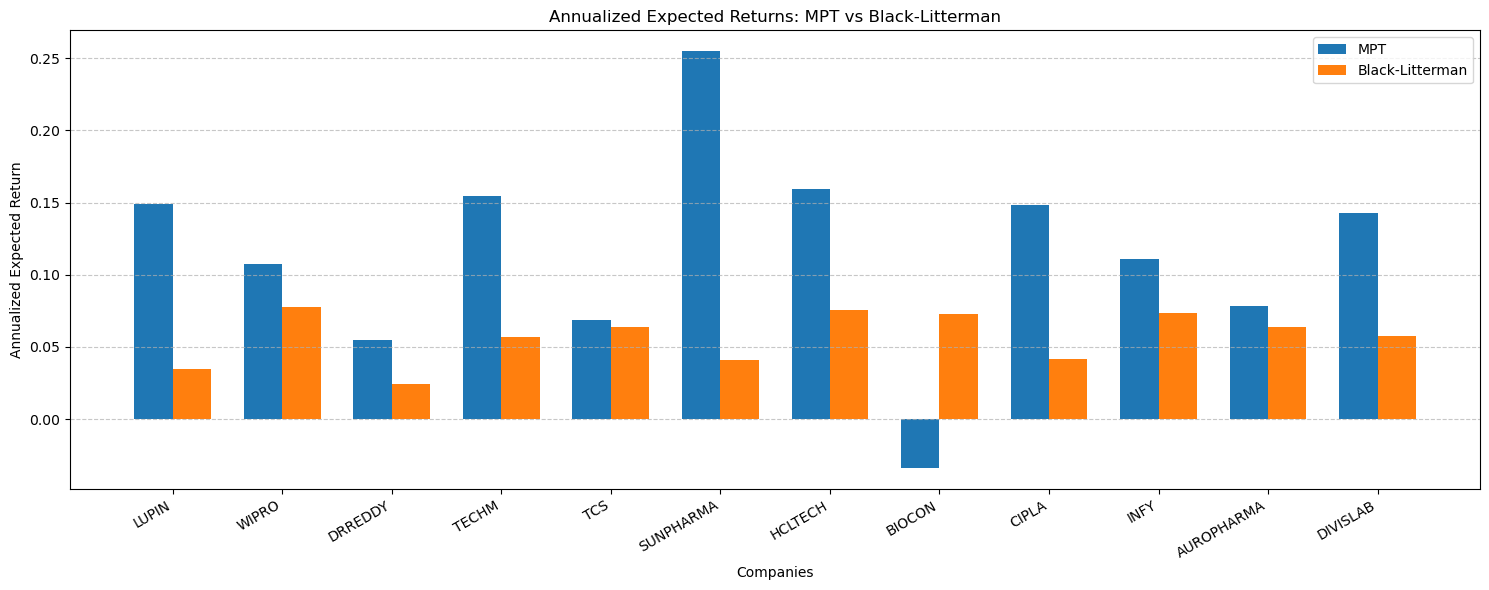

In [16]:
import matplotlib.pyplot as plt
import numpy as np

companies = list(prices.columns)
mpt_returns = mean_returns_annual.values   # or your MPT expected returns array
bl_returns = posterior_returns             # already matches order

x = np.arange(len(companies))
width = 0.35

plt.figure(figsize=(15,6))
plt.bar(x - width/2, mpt_returns, width, label='MPT', color='tab:blue')
plt.bar(x + width/2, bl_returns, width, label='Black-Litterman', color='tab:orange')

plt.xlabel('Companies')
plt.ylabel('Annualized Expected Return')
plt.title('Annualized Expected Returns: MPT vs Black-Litterman')
plt.xticks(x, companies, rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Bar chart: Portfolio Weights by Model (MPT vs Black-Litterman)

ValueError: 'facecolor' or 'color' argument must be a valid color or sequence of colors.

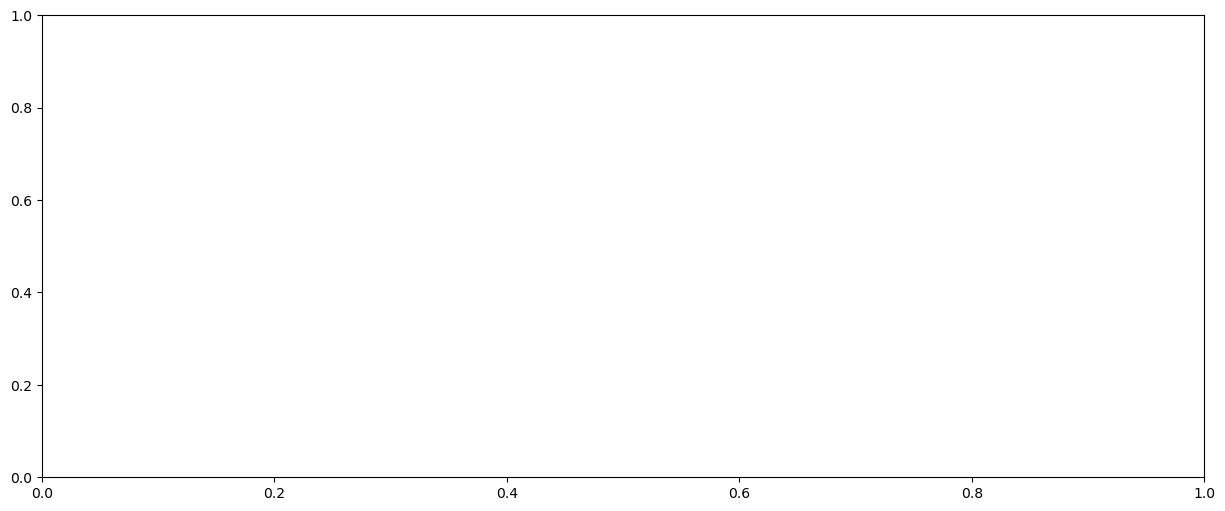

In [17]:
mpt_weights = w_tan                # from your global minimum variance/tangency portfolio
bl_weights = bl_weights            # from Black-Litterman output

plt.figure(figsize=(15,6))
plt.bar(x - width/2, mpt_weights, width, label='MPT Weight', color='tab: blue')
plt.bar(x + width/2, bl_weights, width, label='BL Weight', color='tab:orange')

plt.xlabel('Companies')
plt.ylabel('Portfolio Weight')
plt.title('Portfolio Weights: MPT vs Black-Litterman Optimization')
plt.xticks(x, companies, rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Bar chart: Weight Differences (Black-Litterman - MPT)

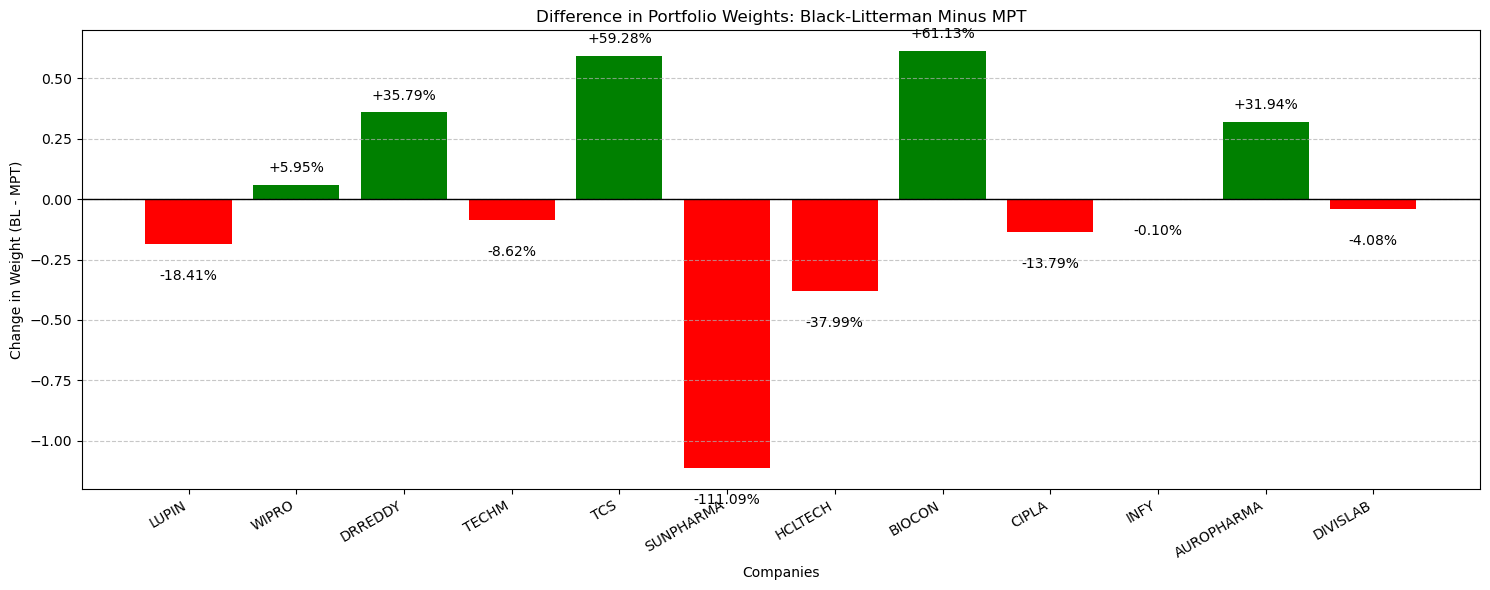

In [18]:
diff_weights = bl_weights - mpt_weights

plt.figure(figsize=(15,6))
bars = plt.bar(companies, diff_weights, color=['green' if w > 0 else 'red' for w in diff_weights])

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Companies')
plt.ylabel('Change in Weight (BL - MPT)')
plt.title('Difference in Portfolio Weights: Black-Litterman Minus MPT')
plt.xticks(rotation=30, ha='right')

# Annotate bars with change
for bar in bars:
    plt.annotate(f'{bar.get_height():+.2%}',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 7 if bar.get_height() > 0 else -18),
                 textcoords='offset points',
                 ha='center', va='bottom' if bar.get_height() > 0 else 'top')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Table: Model Comparison Metrics

In [19]:
print(f"{'Metric':<25} {'MPT':>20} {'Black-Litterman':>20}")
print("-" * 65)
print(f"{'Expected Return':<25} {port_ret:>19.2%} {bl_return:>19.2%}")
print(f"{'Volatility':<25} {port_vol:>19.2%} {bl_volatility:>19.2%}")
print(f"{'Sharpe Ratio':<25} {sharpe:>19.2f} {bl_sharpe:>19.2f}")

Metric                                     MPT      Black-Litterman
-----------------------------------------------------------------
Expected Return                        46.31%               6.96%
Volatility                             31.16%              15.03%
Sharpe Ratio                             0.16                0.06


## Bar Chart: Black-Litterman Annualized Expected Returns Per Stock

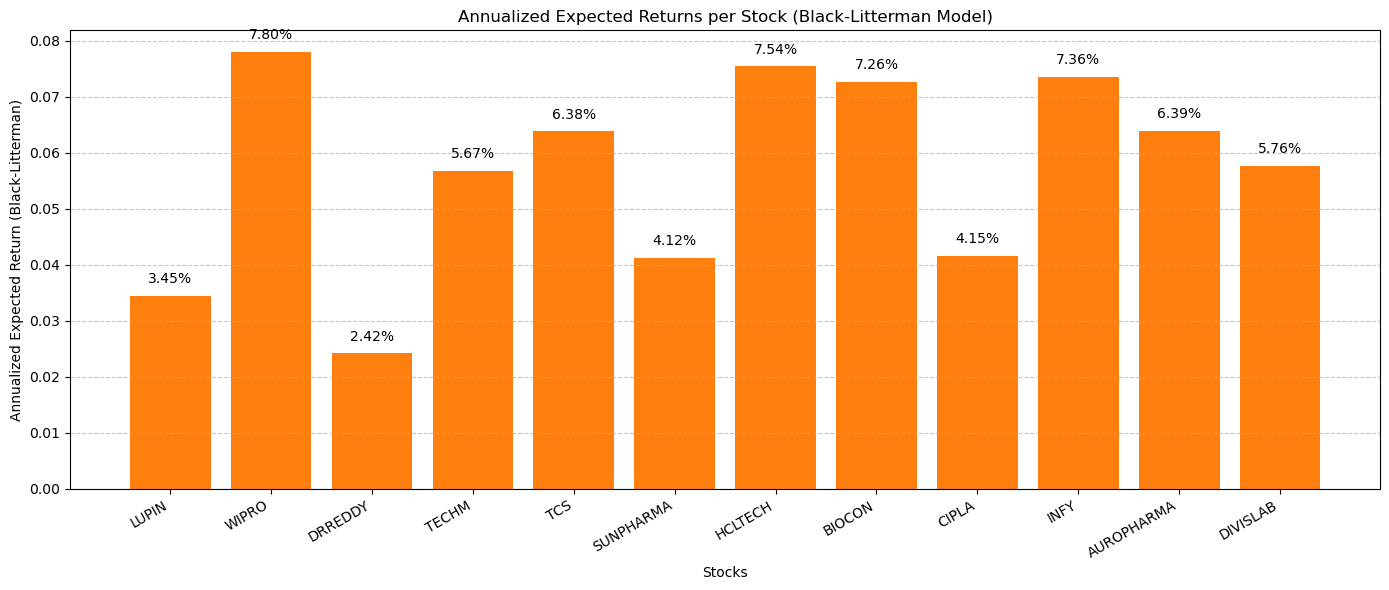

In [20]:
import matplotlib.pyplot as plt
import numpy as np

companies = list(prices.columns)
bl_returns = posterior_returns  # Black-Litterman expected returns, as annualized

plt.figure(figsize=(14,6))
bars = plt.bar(companies, bl_returns, color='tab:orange')
plt.xlabel('Stocks')
plt.ylabel('Annualized Expected Return (Black-Litterman)')
plt.title('Annualized Expected Returns per Stock (Black-Litterman Model)')
plt.xticks(rotation=30, ha='right')

# Annotate each bar
for bar in bars:
    plt.annotate(f'{bar.get_height():.2%}', 
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 7),
                 textcoords='offset points', 
                 ha='center', va='bottom')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Bar Chart: MPT Annualized Expected Returns Per Stock

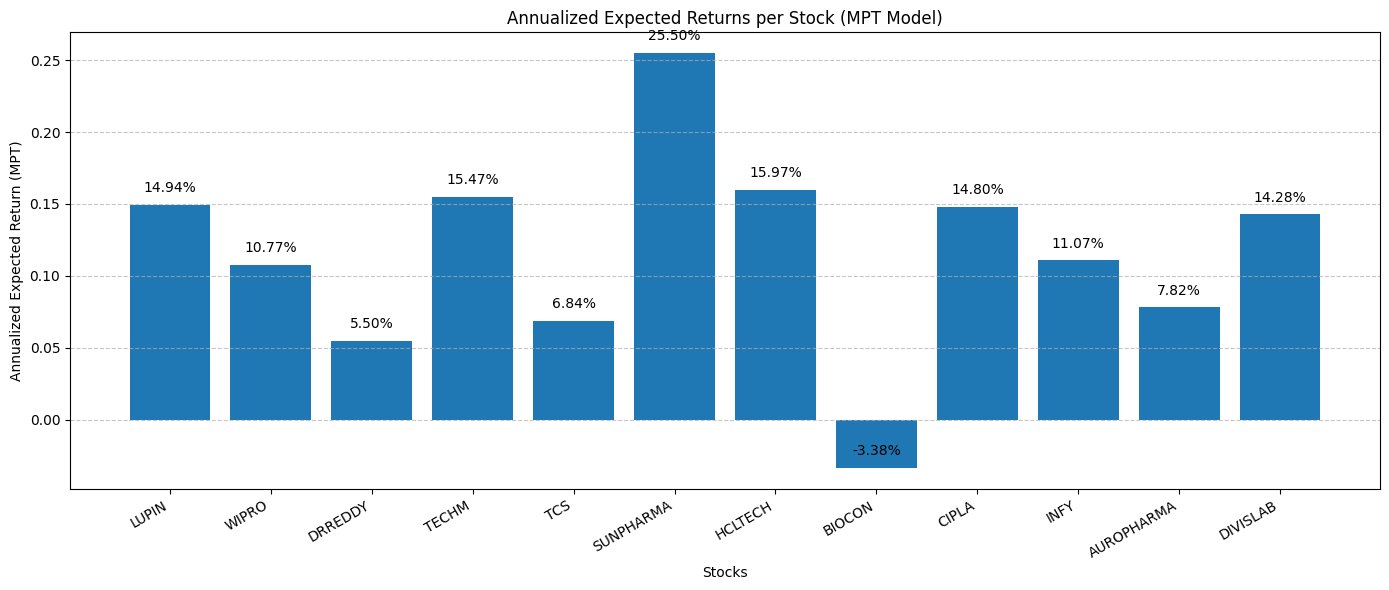

In [46]:
import matplotlib.pyplot as plt
import numpy as np

companies = list(prices.columns)
mpt_returns = mean_returns_annual.values  # Each stock's expected return from your MPT model

plt.figure(figsize=(14,6))
bars = plt.bar(companies, mpt_returns, color='tab:blue')
plt.xlabel('Stocks')
plt.ylabel('Annualized Expected Return (MPT)')
plt.title('Annualized Expected Returns per Stock (MPT Model)')
plt.xticks(rotation=30, ha='right')

# Annotate each bar with percentage
for bar in bars:
    plt.annotate(f'{bar.get_height():.2%}', 
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 7),
                 textcoords='offset points', 
                 ha='center', va='bottom')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
